# Setup

**Note: Module import issues**

When running the notebook on Google Colab, there might be issues installing the necessary local editable modules, `slicegpt` and `sliced_rag` (i.e. the module is successfully installed, but importing it throws a ModuleNotFoundError).

The following steps usually fix the problem:
1. Run notebook up to the cell where the `slicegpt` module is installed.
2. Click "Restart Session" on the top bar (don't disconnect the runtime)
3. Run notebook up to the cell where our module (`sliced_rag`) is installed.
4. Click "Restart Session" again.
5. Run notebook normally. Both libraries should be successfully imported now.

This notebook, specifically, is used in order to run the slicegpt algorithm on original models.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!pip install -e ".[experiment]"

In [ ]:
import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_opt1.3B")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt1.3B") # Change the log and model dir according to your needs, e.g., "logs_qwen2_0.5B", "models_qwen2_0.5B", "logs_qwen2_1.5B", "models_qwen2_1.5B-Instruct", etc.

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

sparsities = [0.0, 0.1, 0.25, 0.4, 0.6]
datasets = ["wikitext2", "squad2", "hotpotqa", "coqa"]

print("Logs in:", LOG_DIR)
print("Models in:", MODEL_DIR)

Logs in: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/logs_opt1.3B
Models in: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt1.3B


In [ ]:
import subprocess
from datetime import datetime

def run_slicegpt(dataset, sparsity):
    log_name = f"{dataset}_s{sparsity:.2f}.txt".replace(".", "p")  # 0.25 -> 0p25
    log_path = os.path.join(LOG_DIR, log_name)

    if os.path.exists(log_path):
        print(f"[SKIP] Log already exists for {dataset}, sparsity={sparsity}: {log_path}")
        return

    save_dir = os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}".replace(".", "p"))
    os.makedirs(save_dir, exist_ok=True)

    cmd = [
        "python", "/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/experiments/run_slicegpt.py",
        "--model", "facebook/opt-1.3b", # Change the model name according to your needs, e.g., "Qwen/Qwen2-0.5B", "Qwen/Qwen2-1.5B-Instruct", "facebook/opt-1.3b", etc.
        "--cal-dataset", dataset,
        "--save-dir", save_dir,
        "--sparsity", str(sparsity),
        "--device", "cuda:0",
        "--eval-baseline",
        "--no-wandb",
        #"--save-rotation-matrices", #to store rotation matrices for later analysis, for example for PCA analysis
        #"--save-hidden-states", #to store hidden states for later analysis, for example for PCA analysis
    ]

    print("\n=====================================================")
    print("Running:", " ".join(cmd))
    print("Log file:", log_path)
    print("Start:", datetime.now())
    print("=====================================================\n")

    with open(log_path, "w") as f:
        # Stream output to both cell and file
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end="")   # to notebook
            f.write(line)         # to log file

    ret = process.wait()
    print("\nFinished with return code:", ret)
    print("End:", datetime.now())

for dataset in datasets:
    for s in sparsities:
        run_slicegpt(dataset, s)


In [ ]:
import os, re
import pandas as pd

rows = []

time_pattern = re.compile(r"Time spent on evaluation:\s+(\d+):(\d+):(\d+\.\d+)")
ppl_pattern = re.compile(r"Original ppl:\s+([0-9.]+)")
ppl_after_pattern = re.compile(r"After rotating and slicing\s+([0-9.]+)")
params_orig_pattern = re.compile(r"Original model parameters:\s+([0-9,]+)")
params_sliced_pattern = re.compile(r"Sliced model parameters:\s+([0-9,]+)")

def hms_to_seconds(h, m, s):
    return int(h) * 3600 + int(m) * 60 + float(s)

print("LOG_DIR:", LOG_DIR)
print("Files:", os.listdir(LOG_DIR))

for fname in os.listdir(LOG_DIR):
  # process only files whose name ends with "txt" (with or without a dot)
  if not fname.lower().endswith("txt"):
      continue

  print("\n--- Parsing", fname, "---")
  path = os.path.join(LOG_DIR, fname)
  with open(path, "r") as f:
      text = f.read()

  # ---- clean the filename first ----
  clean = fname

  # remove Windows duplicate suffix like " (1)"
  clean = re.sub(r"\s*\(\d+\)$", "", clean)

  # strip trailing ".txt", "txt", ".ptxt" or "ptxt"
  clean = re.sub(r"(?:\.?ptxt|\.?txt)$", "", clean, flags=re.IGNORECASE)

  base = clean  # now something like "squad_s0p00"

  # Decode dataset + sparsity from filename
  dataset, s_part = base.split("_s", 1)
  sparsity = float(s_part.replace("p", "."))

  # --- everything below stays the same ---
  ppl_orig_match = ppl_pattern.search(text)
  if not ppl_orig_match:
      print("  !! No ppl baseline in", fname)
      continue
  ppl_orig = float(ppl_orig_match.group(1))

  ppl_after_match = ppl_after_pattern.search(text)
  if not ppl_after_match:
      print("  !! No ppl after slicing in", fname)
      continue
  ppl_after = float(ppl_after_match.group(1))

  po = params_orig_pattern.search(text)
  ps = params_sliced_pattern.search(text)
  if not (po and ps):
      print("  !! No params in", fname)
      continue
  params_orig = int(po.group(1).replace(",", ""))
  params_sliced = int(ps.group(1).replace(",", ""))

  times = time_pattern.findall(text)
  if len(times) < 2:
      print("  !! Not enough time lines in", fname)
      continue
  t_base = hms_to_seconds(*times[0])
  t_sliced = hms_to_seconds(*times[1])

  row = {
      "dataset": dataset,
      "sparsity": sparsity,
      "ppl_baseline": ppl_orig,
      "ppl_sliced": ppl_after,
      "params_orig": params_orig,
      "params_sliced": params_sliced,
      "param_frac": params_sliced / params_orig,
      "eval_time_baseline": t_base,
      "eval_time_sliced": t_sliced,
      "speedup": t_base / t_sliced if t_sliced > 0 else None,
  }
  print("  Parsed row:", row)
  rows.append(row)

df = pd.DataFrame(rows)
df


The next cells are used in order to do an basic analysis on the pruned models.

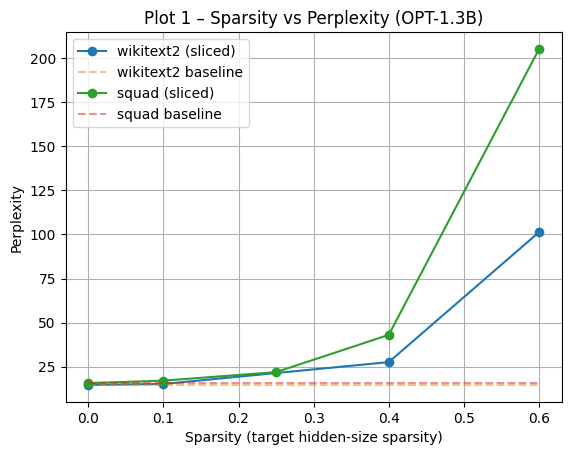

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for dataset in datasets:
    sub = df[(df["dataset"] == dataset)]
    plt.plot(sub["sparsity"], sub["ppl_sliced"], marker="o", label=f"{dataset} (sliced)")
    plt.plot(sub["sparsity"], sub["ppl_baseline"], "--", alpha=0.5, label=f"{dataset} baseline")

plt.xlabel("Sparsity (target hidden-size sparsity)")
plt.ylabel("Perplexity")
plt.title("Plot 1 – Sparsity vs Perplexity (OPT-1.3B)")
plt.legend()
plt.grid(True)
plt.show()

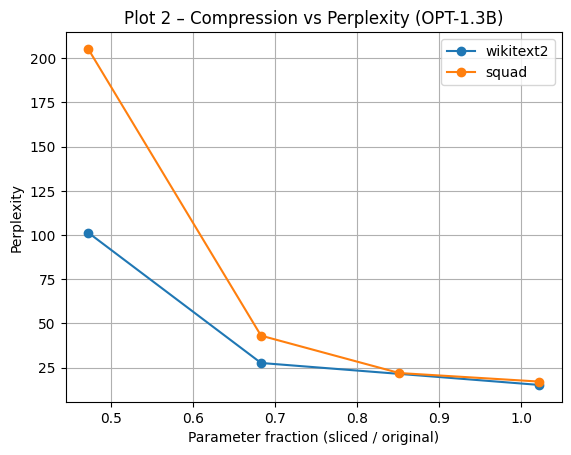

In [ ]:
plt.figure()
for dataset in datasets:
    sub = df[(df["dataset"] == dataset) & (df["sparsity"] > 0)]
    plt.plot(sub["param_frac"], sub["ppl_sliced"], marker="o", label=f"{dataset}")

plt.xlabel("Parameter fraction (sliced / original)")
plt.ylabel("Perplexity")
plt.title("Plot 2 – Compression vs Perplexity (OPT-1.3B)")
plt.grid(True)
plt.legend()
plt.show()


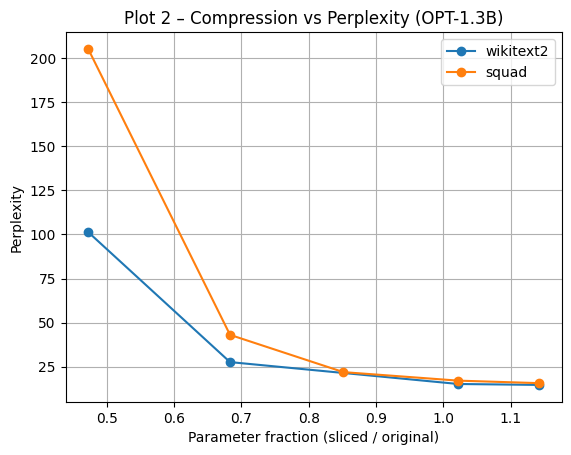

In [ ]:
plt.figure()
for dataset in datasets:
    sub = df[(df["dataset"] == dataset)]
    plt.plot(sub["param_frac"], sub["ppl_sliced"], marker="o", label=f"{dataset}")

plt.xlabel("Parameter fraction (sliced / original)")
plt.ylabel("Perplexity")
plt.title("Plot 2 – Compression vs Perplexity (OPT-1.3B)")
plt.grid(True)
plt.legend()
plt.show()


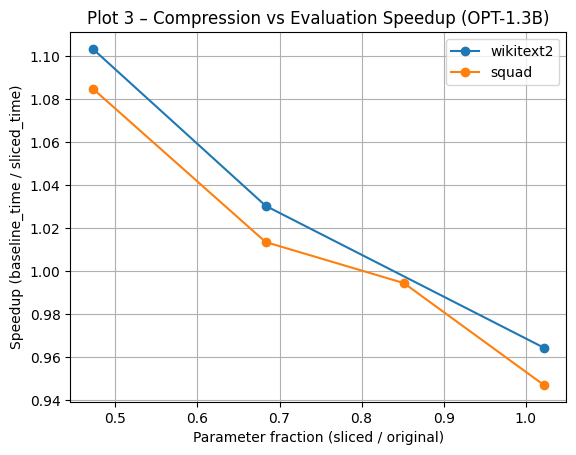

In [ ]:
plt.figure()
for dataset in datasets:
    sub = df[(df["dataset"] == dataset) & (df["sparsity"] > 0)]
    plt.plot(sub["param_frac"], sub["speedup"], marker="o", label=f"{dataset}")

plt.xlabel("Parameter fraction (sliced / original)")
plt.ylabel("Speedup (baseline_time / sliced_time)")
plt.title("Plot 3 – Compression vs Evaluation Speedup (OPT-1.3B)")
plt.grid(True)
plt.legend()
plt.show()


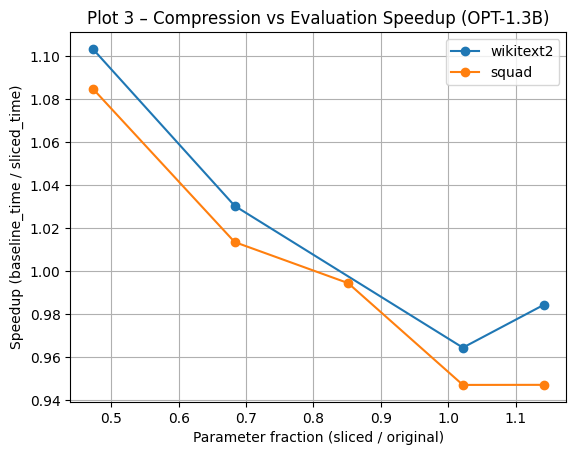

In [ ]:
plt.figure()
for dataset in datasets:
    sub = df[(df["dataset"] == dataset)]
    plt.plot(sub["param_frac"], sub["speedup"], marker="o", label=f"{dataset}")

plt.xlabel("Parameter fraction (sliced / original)")
plt.ylabel("Speedup (baseline_time / sliced_time)")
plt.title("Plot 3 – Compression vs Evaluation Speedup (OPT-1.3B)")
plt.grid(True)
plt.legend()
plt.show()
